# Notebook para clasificación binaria con Gradient Boosted Trees con Filtrado por prevalencia del 20%

**Autor:** Daniel de Lara Pérez

**Afiliación:** Universidad Católica de Ávila  

**Fecha:** Septiembre 2026  

### Imports iniciales

In [1]:
#Imports Iniciales

#!pip install optuna
#!pip install "scipy<1.12"
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import optuna
from optuna.samplers import TPESampler
from sklearn.base import clone

### Lectura del archivo CSV

In [2]:
# Read CSV file into a DataFrame
df_metadata = pd.read_csv('SraRunTable.csv')

df_metadata["disease_status"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(Patient|Control)", expand=False)
    .str.lower()
)

df_metadata["disease_status"] = df_metadata["disease_status"].map({
    "control": 0,
    "patient": 1
})

df_metadata["pair_id"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

df_metadata = df_metadata[["Run", "env_medium", "disease_status","pair_id"]]

df_metadata

,Run,env_medium,disease_status,pair_id
0,SRR32936395,Unstimulated saliva,1,17
1,SRR32936396,Unstimulated saliva,0,16
2,SRR32936397,Unstimulated saliva,1,3
3,SRR32936398,Unstimulated saliva,1,16
4,SRR32936408,Unstimulated saliva,1,2
...,...,...,...,...
247,SRR32938727,Supragingival swab,0,6
248,SRR32938728,Supragingival swab,1,6
249,SRR32938729,Supragingival swab,0,5
250,SRR32938733,Supragingival swab,1,4


### Pre-procesado inicial

In [3]:
df_asv = pd.read_csv('asv_table.tsv', sep = '\t', header=1)
df_asvt = df_asv.transpose()
new_header = df_asvt.iloc[0] 
df_asvt = df_asvt[1:] 
df_asvt.columns = new_header
df_asvt.reset_index(level=0, inplace=True, names=["Run"]) 
df_asvt.head()

#OTU ID,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,ad98578086fac11d2c8d482bac525d19,a094de4e58b9f291cdea1600e53ae871,518528979dc71666ec2bba322b9e806b,dec2a6a67a2a8cb475b16c04cd60c712,30a3a61dfd94eef22b368c4e078bcdf2,19322f53614269ad24c1b6e83d85b1a8,8d451bdf92f1a3f59016162bd25ddb2b,234ba3e9c68c5efdb496a08c06eb4fd1,580a3724eadd91834f6b885e8132c4d3,e8035cd0cf8992d4de5c688f1923022a
0,SRR32936402,9477.0,9235.0,8983.0,8878.0,7642.0,7406.0,5917.0,4881.0,4300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,0.0,945.0,9364.0,0.0,0.0,782.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,0.0,811.0,7265.0,11794.0,4946.0,0.0,574.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,0.0,7772.0,19553.0,5817.0,11248.0,0.0,408.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,0.0,6106.0,26832.0,6933.0,17034.0,0.0,2117.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Filtrado por prevalencia del 20%

ASVs con prevalencia ≥ 20%: 552
ASVs totales: 8574
Porcentaje conservado: 6.44%


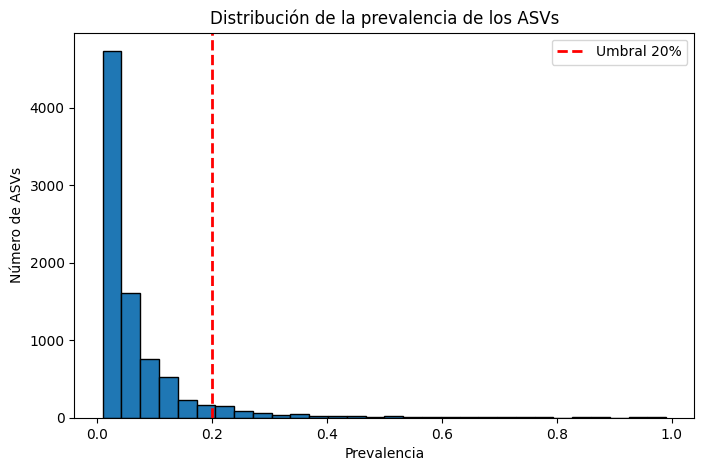

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Quedarse solo con las columnas de ASVs
asv_counts = df_asvt.drop(columns=["Run"])

# Prevalencia de cada ASV (fracción de muestras donde el conteo > 0)
prevalence = (asv_counts > 0).mean(axis=0)

# Número de ASVs que superan el 20%
n_asvs = (prevalence >= 0.2).sum()

print(f"ASVs con prevalencia ≥ 20%: {n_asvs}")
print(f"ASVs totales: {asv_counts.shape[1]}")
print(f"Porcentaje conservado: {100*n_asvs/asv_counts.shape[1]:.2f}%")

# Histograma de prevalencias
plt.figure(figsize=(8,5))
plt.hist(prevalence, bins=30, edgecolor="black")
plt.axvline(0.2, color="red", linestyle="--", linewidth=2,
            label="Umbral 20%")
plt.xlabel("Prevalencia")
plt.ylabel("Número de ASVs")
plt.title("Distribución de la prevalencia de los ASVs")
plt.legend()
plt.show()

In [5]:
# Seleccionar ASVs con prevalencia ≥ 20%
asv_counts_filtered = asv_counts.loc[:, prevalence >= 0.2]

# Comprobar resultados
print(f"ASVs después del filtrado: {asv_counts_filtered.shape[1]}")
print(f"ASVs eliminados: {asv_counts.shape[1] - asv_counts_filtered.shape[1]}")
print(f"Porcentaje conservado: {100*asv_counts_filtered.shape[1]/asv_counts.shape[1]:.2f}%")

# Si quieres volver a incluir la columna Run:
df_asvt_filtered = pd.concat([df_asvt["Run"], asv_counts_filtered], axis=1)
df_asvt_filtered.head()

ASVs después del filtrado: 552
ASVs eliminados: 8022
Porcentaje conservado: 6.44%


,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,25a739f236938a52b28895558f2f4c65,626145cc8bcaf0764330664a8ca9266b,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623
0,SRR32936402,9477.0,9235.0,8878.0,7642.0,7406.0,5917.0,4300.0,3838.0,3437.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,945.0,9364.0,0.0,782.0,164.0,2054.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,811.0,7265.0,11794.0,4946.0,574.0,1870.0,489.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,7772.0,19553.0,5817.0,11248.0,408.0,1771.0,876.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,6106.0,26832.0,6933.0,17034.0,2117.0,2359.0,3806.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Transformación CLR

Para cada observación \(i\), primero se suma 1 a cada componente para evitar
problemas con valores iguales a cero:

$$
x_{ij}^{*} = x_{ij} + 1
$$

A continuación, se calcula la media geométrica de los componentes de cada
observación:

$$
g_i =
\left(
\prod_{j=1}^{D} x_{ij}^{*}
\right)^{1/D}
=
\exp\left(
\frac{1}{D}
\sum_{j=1}^{D}
\ln(x_{ij}^{*})
\right)
$$

Finalmente, se aplica la transformación Centered Log-Ratio (CLR):

$$
\operatorname{CLR}(x_{ij})
=
\ln\left(
\frac{x_{ij}^{*}}{g_i}
\right)
$$

donde \(D\) es el número de variables y \(g_i\) es la media geométrica
de la observación \(i\).

In [6]:
#CLR transform

runs = df_asvt_filtered["Run"]

df_asvtclr = df_asvt_filtered.drop(columns="Run").astype(float)

df_asvtclr = df_asvtclr + 1

gm = np.exp(np.log(df_asvtclr).mean(axis=1))

df_asvtclr = np.log(df_asvtclr.div(gm, axis=0))

df_asvtclr.insert(0, "Run", runs)

df_asvtclr.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,25a739f236938a52b28895558f2f4c65,626145cc8bcaf0764330664a8ca9266b,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041


### Merge de tabla ASVs con la tabla de metadatos

In [7]:
#merge de ambas columnas
mg = pd.merge(df_asvtclr, df_metadata, on="Run", how="left")
mg

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,env_medium,disease_status,pair_id
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,Unstimulated saliva,1,14
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,Unstimulated saliva,1,20
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,Supragingival swab,1,15
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,Unstimulated saliva,0,16
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,Unstimulated saliva,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,SRR32936397,7.272687,5.253448,5.435925,7.422768,7.782894,7.685705,5.271899,5.726705,6.115402,...,3.134115,-1.725697,-1.725697,2.550969,2.631012,-0.339403,-1.725697,Unstimulated saliva,1,3
97,SRR32938719,-1.496125,5.683182,3.831751,7.928762,8.945170,6.510909,5.167007,6.275785,5.445065,...,-1.496125,1.969610,-1.496125,-1.496125,-1.496125,-1.496125,-1.496125,Supragingival swab,0,10
98,SRR32936399,5.863502,6.220812,-1.497873,7.932084,7.217351,7.530225,1.637621,5.964916,6.168348,...,2.191006,-0.399261,-1.497873,1.497859,-1.497873,-1.497873,3.361939,Unstimulated saliva,0,15
99,SRR32938700,-1.413184,0.784041,-1.413184,5.850846,9.801228,5.005181,3.924354,3.722615,5.275171,...,1.764870,-1.413184,-1.413184,1.631339,-1.413184,2.324486,-1.413184,Supragingival swab,1,19


### One-hot encoding para datos categóricos

In [8]:
#ohe
df_analisis_ohe = pd.get_dummies(mg, columns= ['env_medium'], drop_first=False)
df_analisis_ohe.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,disease_status,pair_id,env_medium_Supragingival swab,env_medium_Unstimulated saliva
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,1,14,False,True
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,1,20,False,True
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,1,15,True,False
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,0,16,False,True
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,0,9,False,True


### Asignación de variables objetivo y predictoras

In [9]:
# Variable objetivo
y = df_analisis_ohe["disease_status"]

# Grupos para los folds
groups = df_analisis_ohe["pair_id"]

# Variables predictoras
X = df_analisis_ohe.drop(columns=[
    "Run",
    "disease_status",
    "pair_id"
])
X

,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,23e4c18880db9ea26fff40c84949538a,...,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,env_medium_Supragingival swab,env_medium_Unstimulated saliva
0,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,6.784613,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,False,True
1,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,-1.544053,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,False,True
2,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,-1.323049,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,True,False
3,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,-1.204909,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,False,True
4,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,-1.608041,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,7.272687,5.253448,5.435925,7.422768,7.782894,7.685705,5.271899,5.726705,6.115402,-1.725697,...,-1.725697,3.134115,-1.725697,-1.725697,2.550969,2.631012,-0.339403,-1.725697,False,True
97,-1.496125,5.683182,3.831751,7.928762,8.945170,6.510909,5.167007,6.275785,5.445065,-0.397513,...,-1.496125,-1.496125,1.969610,-1.496125,-1.496125,-1.496125,-1.496125,-1.496125,True,False
98,5.863502,6.220812,-1.497873,7.932084,7.217351,7.530225,1.637621,5.964916,6.168348,-1.497873,...,-0.804726,2.191006,-0.399261,-1.497873,1.497859,-1.497873,-1.497873,3.361939,False,True
99,-1.413184,0.784041,-1.413184,5.850846,9.801228,5.005181,3.924354,3.722615,5.275171,-1.413184,...,-1.413184,1.764870,-1.413184,-1.413184,1.631339,-1.413184,2.324486,-1.413184,True,False


### Clasificación binaria mediante XGBoost con optimización de hiperparámetros

Se entrena y evalúa un clasificador XGBoost mediante validación cruzada estratificada por grupos, optimizando sus hiperparámetros con Optuna y evaluando el rendimiento de cada fold mediante ROC-AUC, F1 y Balanced Accuracy.

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

best_models = []
results = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups), 1
):

    print(f"\n--- Procesando Fold {fold} ---")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    def objective(trial):

        params = {

            "n_estimators": trial.suggest_int(
                "n_estimators",
                100,
                500
            ),

            "max_depth": trial.suggest_int(
                "max_depth",
                2,
                8
            ),

            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True
            ),

            "subsample": trial.suggest_float(
                "subsample",
                0.5,
                1.0
            ),

            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                0.5,
                1.0
            ),

            "min_child_weight": trial.suggest_int(
                "min_child_weight",
                1,
                10
            ),

            "gamma": trial.suggest_float(
                "gamma",
                0,
                5
            ),

            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                1e-4,
                10,
                log=True
            ),

            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                1e-4,
                10,
                log=True
            ),

            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "random_state": 42,
            "n_jobs": -1
        }

        inner_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        cv_scores = []

        for in_train_idx, in_val_idx in inner_cv.split(
            X_train,
            y_train,
            groups_train
        ):

            X_in_train = X_train.iloc[in_train_idx]
            X_val = X_train.iloc[in_val_idx]

            y_in_train = y_train.iloc[in_train_idx]
            y_val = y_train.iloc[in_val_idx]

            model = XGBClassifier(**params)

            model.fit(
                X_in_train,
                y_in_train
            )

            scores = model.predict_proba(
                X_val
            )[:, 1]

            cv_scores.append(
                roc_auc_score(
                    y_val,
                    scores
                )
            )

        return np.mean(cv_scores)

    sampler = optuna.samplers.TPESampler(seed=42)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler
    )

    study.optimize(
        objective,
        n_trials=50
    )

    best_params = study.best_params

    best_params.update({

        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1

    })

    print(best_params)

    best_model = XGBClassifier(
        **best_params
    )

    best_model.fit(
        X_train,
        y_train
    )

    test_preds = best_model.predict(
        X_test
    )

    test_scores = best_model.predict_proba(
        X_test
    )[:, 1]

    fold_auc = roc_auc_score(
        y_test,
        test_scores
    )

    fold_f1_weighted = f1_score(
        y_test,
        test_preds,
        average="weighted"
    )

    fold_f1_macro = f1_score(
        y_test,
        test_preds,
        average="macro"
    )

    fold_bal_acc = balanced_accuracy_score(
        y_test,
        test_preds
    )

    results.append({

        "fold": fold,
        "roc_auc": fold_auc,
        "f1_weighted": fold_f1_weighted,
        "f1_macro": fold_f1_macro,
        "balanced_accuracy": fold_bal_acc,
        "best_params": best_params

    })

    best_models.append(best_model)

    print(f"ROC-AUC      (Fold {fold}): {fold_auc:.4f}")
    print(f"F1 weighted  (Fold {fold}): {fold_f1_weighted:.4f}")
    print(f"F1 macro     (Fold {fold}): {fold_f1_macro:.4f}")
    print(f"Balanced Acc (Fold {fold}): {fold_bal_acc:.4f}")


--- Procesando Fold 1 ---
{'n_estimators': 409, 'max_depth': 5, 'learning_rate': 0.03106600124882687, 'subsample': 0.7447439543868675, 'colsample_bytree': 0.7287718202877406, 'min_child_weight': 3, 'gamma': 0.7393612415417332, 'reg_alpha': 0.019368084677236472, 'reg_lambda': 0.00010928812703952503, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}
ROC-AUC      (Fold 1): 0.7879
F1 weighted  (Fold 1): 0.8261
F1 macro     (Fold 1): 0.8258
Balanced Acc (Fold 1): 0.8258

--- Procesando Fold 2 ---
{'n_estimators': 412, 'max_depth': 5, 'learning_rate': 0.02021225099242274, 'subsample': 0.7286735310595321, 'colsample_bytree': 0.8542578844625922, 'min_child_weight': 6, 'gamma': 0.4834885880505506, 'reg_alpha': 0.001386421960111826, 'reg_lambda': 0.2194025496693799, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}
ROC-AUC      (Fold 2): 0.5900
F1 weighted  (Fold 2): 0.6491
F1 macro     (Fold 2): 0.6491
Balanced

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_score,
    recall_score
)

# Definir modelo elegido

final_model = best_models[0]

In [13]:
print(final_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7287718202877406, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=0.7393612415417332, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03106600124882687,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=409, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)


### Evaluación final del modelo GBT mediante validación cruzada

Se evalúa el modelo GBT optimizado mediante validación cruzada estratificada por grupos, recopilando las predicciones y puntuaciones de cada fold y calculando las métricas ROC-AUC, Balanced Accuracy y F1 weighted.

In [14]:
from sklearn.base import clone

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_true_all = []
y_pred_all = []
y_score_all = []

fold_results = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups), 1
):

    print(f"\n--- Fold {fold} ---")

    model_fold = clone(final_model)

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Entrenar
    model_fold.fit(
        X_train,
        y_train
    )

    # Predicción de clase
    y_pred = model_fold.predict(
        X_test
    )

    # Probabilidades para ROC
    y_score = model_fold.predict_proba(
        X_test
    )[:, 1]

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    y_score_all.extend(y_score)

    fold_auc = roc_auc_score(
        y_test,
        y_score
    )

    fold_bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    fold_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    fold_results.append({
        "fold": fold,
        "ROC-AUC": fold_auc,
        "Balanced Accuracy": fold_bal_acc,
        "F1 weighted": fold_f1
    })

    print(f"ROC-AUC: {fold_auc:.4f}")
    print(f"Balanced Accuracy: {fold_bal_acc:.4f}")
    print(f"F1 weighted: {fold_f1:.4f}")


--- Fold 1 ---
ROC-AUC: 0.7879
Balanced Accuracy: 0.8258
F1 weighted: 0.8261

--- Fold 2 ---
ROC-AUC: 0.7000
Balanced Accuracy: 0.7500
F1 weighted: 0.7494

--- Fold 3 ---
ROC-AUC: 0.6000
Balanced Accuracy: 0.5500
F1 weighted: 0.5489

--- Fold 4 ---
ROC-AUC: 0.7750
Balanced Accuracy: 0.6500
F1 weighted: 0.6580

--- Fold 5 ---
ROC-AUC: 0.7500
Balanced Accuracy: 0.6000
F1 weighted: 0.5833


### Evaluación global del rendimiento del modelo GBT

Se calculan las principales métricas de clasificación sobre todas las predicciones out-of-fold y se generan el informe de clasificación, la matriz de confusión, la curva ROC y el resumen del rendimiento obtenido en cada fold.

#### Informe de Clasificación

In [15]:
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_score_all = np.array(y_score_all)


accuracy = accuracy_score(
    y_true_all,
    y_pred_all
)

balanced_acc = balanced_accuracy_score(
    y_true_all,
    y_pred_all
)

roc_auc = roc_auc_score(
    y_true_all,
    y_score_all
)

f1_macro = f1_score(
    y_true_all,
    y_pred_all,
    average="macro"
)

f1_weighted = f1_score(
    y_true_all,
    y_pred_all,
    average="weighted"
)

precision = precision_score(
    y_true_all,
    y_pred_all
)

recall = recall_score(
    y_true_all,
    y_pred_all
)


print(f"Accuracy:            {accuracy:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print(f"ROC-AUC:             {roc_auc:.4f}")
print(f"F1 macro:            {f1_macro:.4f}")
print(f"F1 weighted:         {f1_weighted:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")


print("\nClassification report:\n")

print(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=[
            "Control",
            "Paciente"
        ]
    )
)

Accuracy:            0.6832
Balanced Accuracy:   0.6833
ROC-AUC:             0.7298
F1 macro:            0.6831
F1 weighted:         0.6831
Precision:           0.6939
Recall:              0.6667

Classification report:

              precision    recall  f1-score   support

     Control       0.67      0.70      0.69        50
    Paciente       0.69      0.67      0.68        51

    accuracy                           0.68       101
   macro avg       0.68      0.68      0.68       101
weighted avg       0.68      0.68      0.68       101



#### Matriz de confusión

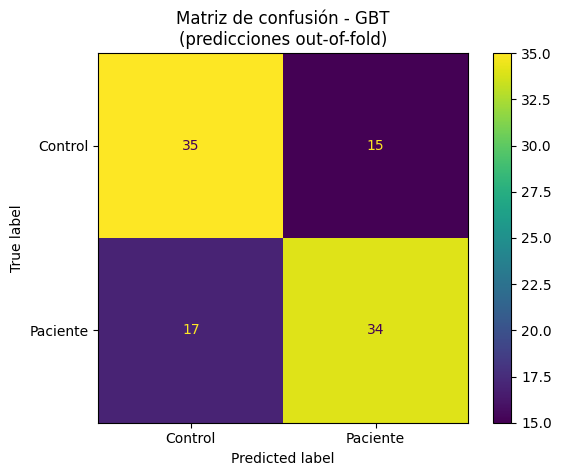

In [29]:
# Matriz de confusión


cm = confusion_matrix(
    y_true_all,
    y_pred_all
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Control",
        "Paciente"
    ]
)


disp.plot(
    values_format="d"
)

plt.title(
    "Matriz de confusión - GBT\n(predicciones out-of-fold)"
)

plt.show()

 #### Curva ROC

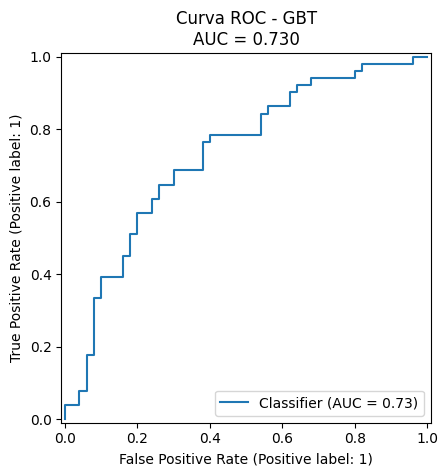

In [30]:
# Curva ROC

RocCurveDisplay.from_predictions(
    y_true_all,
    y_score_all
)

plt.title(
    f"Curva ROC - GBT\nAUC = {roc_auc:.3f}"
)

plt.show()

#### Resumen del rendimiento obtenido en cada fold.

In [18]:
# Tabla resumen de folds


fold_results = pd.DataFrame(
    fold_results
)

print("\nResultados por fold:")
display(fold_results)


print("\nMedia ± desviación estándar:")
display(
    fold_results.drop(columns="fold")
    .agg(["mean","std"])
)


Resultados por fold:


,fold,ROC-AUC,Balanced Accuracy,F1 weighted
0,1,0.787879,0.825758,0.826087
1,2,0.700000,0.750000,0.749373
2,3,0.600000,0.550000,0.548872
3,4,0.775000,0.650000,0.658009
4,5,0.750000,0.600000,0.583333



Media ± desviación estándar:


,ROC-AUC,Balanced Accuracy,F1 weighted
mean,0.722576,0.675152,0.673135
std,0.076321,0.112058,0.115045


# Interpretabilidad con SHAP

### Interpretación de variables mediante SHAP

Se calcula la importancia de las variables mediante valores SHAP en cada fold de la validación cruzada y se resumen sus valores medios, desviaciones estándar y coeficiente de variación para identificar las variables con mayor contribución al modelo GBT.

In [19]:
import warnings
warnings.filterwarnings("ignore")

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold


outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


shap_values_all = []
X_test_all = []


for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups), 1
):

    print(f"\n========== Fold {fold} ==========")


    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]



    model_fold = clone(final_model)

    model_fold.fit(
        X_train,
        y_train
    )



    explainer = shap.TreeExplainer(
        model_fold
    )


    shap_values = explainer.shap_values(
        X_test
    )


    # Guardar valores SHAP del fold
    shap_values_all.append(
        shap_values
    )

    X_test_all.append(
        X_test
    )


    print(f"Fold {fold} terminado")


========== Fold 1 ==========
Fold 1 terminado

========== Fold 2 ==========
Fold 2 terminado

========== Fold 3 ==========
Fold 3 terminado

========== Fold 4 ==========
Fold 4 terminado

========== Fold 5 ==========
Fold 5 terminado


In [20]:
# Unir todos los test externos
X_test_oof = pd.concat(
    X_test_all
)

shap_values_oof = np.vstack(
    shap_values_all
)


# Importancia media absoluta
shap_importance = pd.Series(
    np.abs(shap_values_oof).mean(axis=0),
    index=X.columns
)


shap_importance = (
    shap_importance
    .sort_values(ascending=False)
)


display(
    shap_importance.head(20)
)

e73baa1f1f54477d80a05671ddde7e6e    0.284429
20b7f0547e6b5c001a22558959826f31    0.283167
666c0e00412ea3071b1ba423b47769e3    0.227506
8710e9cd660b2d5fdc2ad2910a623cb5    0.214339
64a2df4c00208e613cc05e875b0e5563    0.177366
ed42b6b2499adb6145309733ea878a76    0.160876
4c1ee149efcce6f1fbf7a205ed46be8b    0.155352
790d7f32ce0b5f183d3273c76f2e8831    0.150502
7fc0a0722625691737c174ab2ad8cbf7    0.131236
be8e58e5eef5a9b03da7d10d5f253460    0.129025
b2a1f7c5fc62e5d70ecf966f1752a42c    0.119656
2d7fe3776e4f612c8354f37f4083bd3a    0.101411
808e5d4ccc47d0bc9de0a3958e9ec5a0    0.100671
06cc00ee92f02ef534cc0e05414afdbc    0.096819
e70ca6f4caf530dd543eb6c0446341c8    0.086848
b33f39645c2a222859fa4ab7e0a31a14    0.085804
8fa686864ea70b1a8f908fd57efc6fa9    0.084996
59b4e0fab0744f792c28a1e3e8649f03    0.084660
bcd020af756b75104ab8c1d8cec1a7d7    0.077817
96de4125012cb3e244cafa732deddd0f    0.072846
dtype: float32

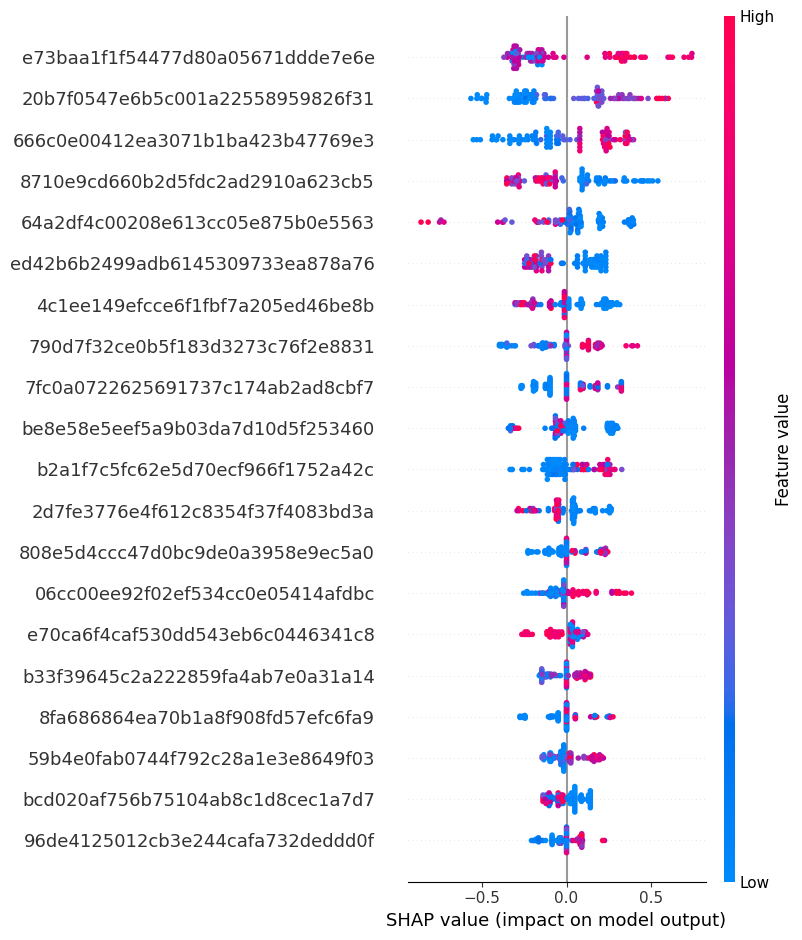

In [21]:
shap.summary_plot(
    shap_values_oof,
    X_test_oof,
    max_display=20
)

### Visualización de las variables más importantes según SHAP

Se representan las 20 ASVs con mayor importancia media según el valor absoluto de SHAP, facilitando la identificación de las variables que más contribuyen a las predicciones del modelo.

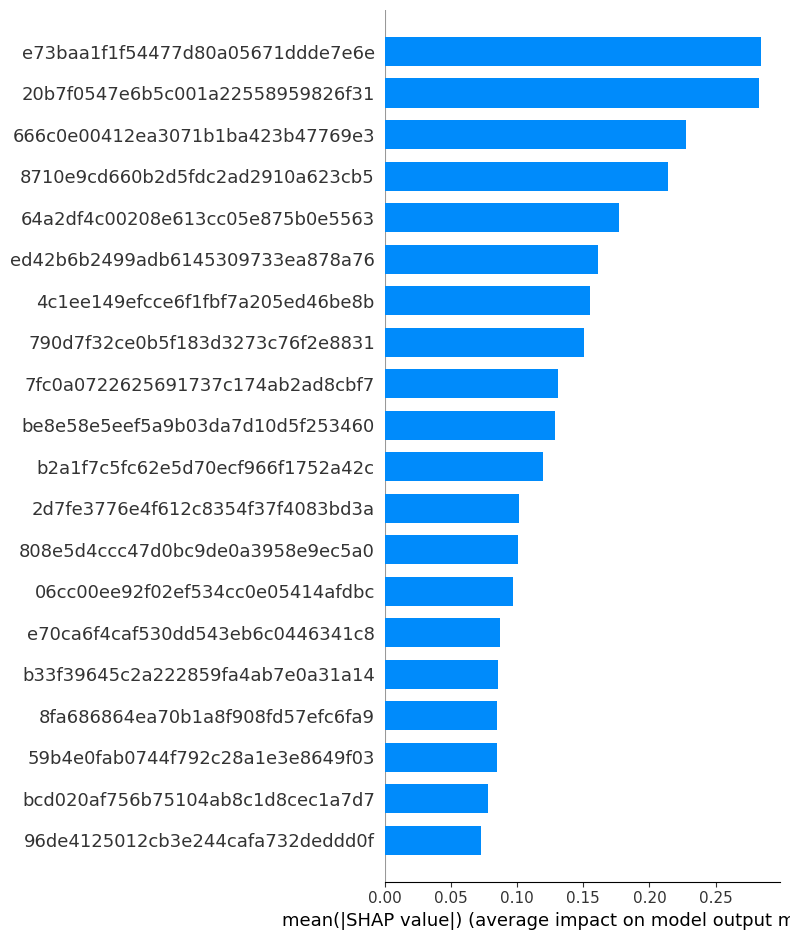

In [22]:
shap.summary_plot(
    shap_values_oof,
    X_test_oof,
    plot_type="bar",
    max_display=20
)

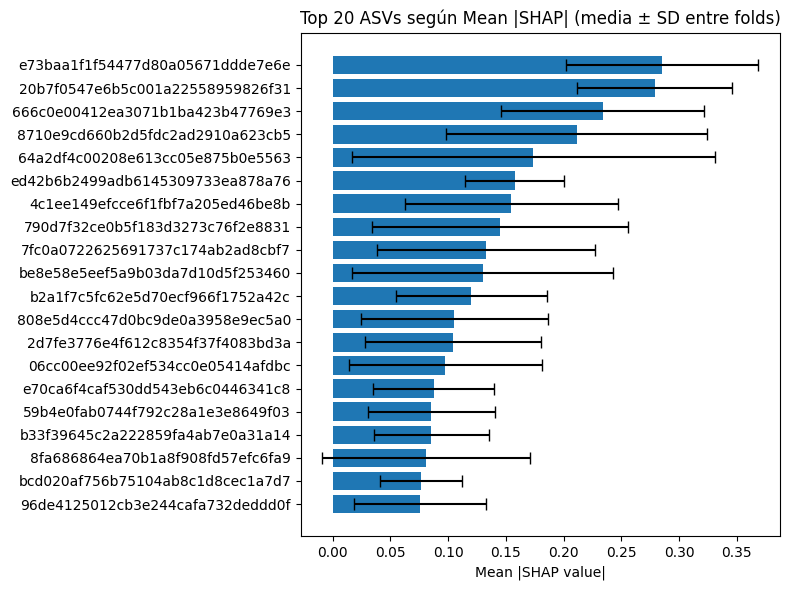

In [23]:
# IMPORTANCIA SHAP POR FOLD
shap_importances = []

for shap_values in shap_values_all:

    importance = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X.columns
    )

    shap_importances.append(
        importance
    )


shap_df = pd.concat(
    shap_importances,
    axis=1
)

shap_df.columns = [
    f"Fold_{i}"
    for i in range(1, len(shap_importances)+1)
]

shap_df["Mean_SHAP"] = shap_df.mean(axis=1)
shap_df["Std_SHAP"] = shap_df.std(axis=1)

shap_df = shap_df.sort_values(
    "Mean_SHAP",
    ascending=False
)
top = (
    shap_df
    .head(20)
    .sort_values("Mean_SHAP")
)

plt.figure(figsize=(8,6))

plt.barh(
    top.index,
    top["Mean_SHAP"],
    xerr=top["Std_SHAP"],
    ecolor="black",
    capsize=4
)

plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 ASVs según Mean |SHAP| (media ± SD entre folds)")

plt.tight_layout()
plt.show()

### Selección de variables mediante BorutaSHAP

Se aplica BorutaSHAP de forma independiente en cada fold de la validación cruzada, utilizando únicamente los datos de entrenamiento para identificar variables aceptadas, tentativas y rechazadas según su importancia SHAP.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from BorutaShap import BorutaShap
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold



n_splits = 5

boruta_cv = StratifiedGroupKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)


accepted_by_fold = []
tentative_by_fold = []
rejected_by_fold = []

fold_summary = []


# BORUTASHAP POR FOLD

for fold, (train_idx, test_idx) in enumerate(
    boruta_cv.split(X, y, groups),
    start=1
):

    print(f"\n========== BorutaSHAP Fold {fold} ==========")

    # BorutaSHAP utiliza exclusivamente el train externo
    X_fold = X.iloc[train_idx].copy()
    y_fold = y.iloc[train_idx].copy()

    # Modelo independiente con los hiperparámetros elegidos
    model_fold = clone(final_model)

    selector = BorutaShap(
        model=model_fold,
        importance_measure="shap",
        classification=True
    )

    selector.fit(
        X=X_fold,
        y=y_fold,
        n_trials=50,
        random_state=42 + fold,
        sample=False,

        # Evita el split interno aleatorio que no respeta groups
        train_or_test="train",

        normalize=True,
        verbose=False
    )

    # Resultados del fold
    accepted = sorted(selector.accepted)
    tentative = sorted(selector.tentative)
    rejected = sorted(selector.rejected)

    accepted_by_fold.append(accepted)
    tentative_by_fold.append(tentative)
    rejected_by_fold.append(rejected)

    fold_summary.append({
        "Fold": fold,
        "N_train": len(train_idx),
        "N_test_excluido": len(test_idx),
        "Accepted": len(accepted),
        "Tentative": len(tentative),
        "Rejected": len(rejected)
    })

    print(f"Aceptadas:  {len(accepted)}")
    print(f"Tentativas: {len(tentative)}")
    print(f"Rechazadas: {len(rejected)}")


========== BorutaSHAP Fold 1 ==========


  0%|          | 0/50 [00:00<?, ?it/s]

Aceptadas:  0
Tentativas: 0
Rechazadas: 554

========== BorutaSHAP Fold 2 ==========


  0%|          | 0/50 [00:00<?, ?it/s]

Aceptadas:  0
Tentativas: 0
Rechazadas: 554

========== BorutaSHAP Fold 3 ==========


...

Aceptadas:  1
Tentativas: 0
Rechazadas: 553

========== BorutaSHAP Fold 4 ==========


  0%|          | 0/50 [00:00<?, ?it/s]

Aceptadas:  0
Tentativas: 0
Rechazadas: 554

========== BorutaSHAP Fold 5 ==========


  0%|          | 0/50 [00:00<?, ?it/s]

Aceptadas:  1
Tentativas: 0
Rechazadas: 553


In [25]:
fold_summary_df = pd.DataFrame(fold_summary)

display(fold_summary_df)

,Fold,N_train,N_test_excluido,Accepted,Tentative,Rejected
0,1,78,23,0,0,554
1,2,81,20,0,0,554
2,3,81,20,1,0,553
3,4,83,18,0,0,554
4,5,81,20,1,0,553


In [26]:
def count_fold_occurrences(feature_lists):
    """
    Cuenta en cuántos folds aparece cada variable.
    set() evita contar una variable más de una vez dentro del mismo fold.
    """
    return Counter(
        feature
        for feature_list in feature_lists
        for feature in set(feature_list)
    )


accepted_counts = count_fold_occurrences(accepted_by_fold)
tentative_counts = count_fold_occurrences(tentative_by_fold)
rejected_counts = count_fold_occurrences(rejected_by_fold)


boruta_consistency = pd.DataFrame({
    "Feature": X.columns
})

boruta_consistency["Accepted_folds"] = (
    boruta_consistency["Feature"]
    .map(accepted_counts)
    .fillna(0)
    .astype(int)
)

boruta_consistency["Tentative_folds"] = (
    boruta_consistency["Feature"]
    .map(tentative_counts)
    .fillna(0)
    .astype(int)
)

boruta_consistency["Rejected_folds"] = (
    boruta_consistency["Feature"]
    .map(rejected_counts)
    .fillna(0)
    .astype(int)
)

boruta_consistency["Accepted_fraction"] = (
    boruta_consistency["Accepted_folds"] / n_splits
)

boruta_consistency = boruta_consistency.sort_values(
    by=[
        "Accepted_folds",
        "Tentative_folds",
        "Rejected_folds"
    ],
    ascending=[False, False, True]
).reset_index(drop=True)

display(boruta_consistency.head(30))

,Feature,Accepted_folds,Tentative_folds,Rejected_folds,Accepted_fraction
0,e73baa1f1f54477d80a05671ddde7e6e,2,0,3,0.4
1,afc7d633b31eacbcd06f9bd00fc92aba,0,0,5,0.0
2,d08c784d1836f43726d1162eadd9c4a4,0,0,5,0.0
3,b9678f89d81e366818a5f4e9a4dbcbf6,0,0,5,0.0
4,2f2af02b1b3b9b47876e1c1f5c41d976,0,0,5,0.0
5,3307f2605d463abcc42024cdfef4c1fe,0,0,5,0.0
6,0f36313fefd8246ebc2d63bd1b70b6f4,0,0,5,0.0
7,e99ef6d33371880af23ceea3cfd58e56,0,0,5,0.0
8,bccbf6a32db96f7b285bb310e4939979,0,0,5,0.0
9,2df318818bdb95fe9e968c46f24b6694,0,0,5,0.0


In [27]:
tax_dict_azh = pd.read_csv(
    "taxonomy.tsv",
    sep="\t"
)
tax_dict = dict(zip(
    tax_dict_azh["Feature ID"],
    tax_dict_azh["Taxon"]
))

In [28]:
boruta_consistency["Taxon"] = (
    boruta_consistency["Feature"]
    .map(tax_dict)
)

pd.set_option("display.max_colwidth", None)

display(
    boruta_consistency[
        [
            "Taxon",
            "Accepted_folds",
            "Tentative_folds",
            "Rejected_folds",
            "Accepted_fraction"
        ]
    ].head(30)
)

,Taxon,Accepted_folds,Tentative_folds,Rejected_folds,Accepted_fraction
0,d__Bacteria; p__Firmicutes; c__Negativicutes; o__Veillonellales-Selenomonadales; f__Veillonellaceae; g__Dialister,2,0,3,0.4
1,d__Bacteria; p__Firmicutes; c__Negativicutes; o__Veillonellales-Selenomonadales; f__Veillonellaceae; g__Veillonella,0,0,5,0.0
2,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Neisseriaceae; g__Neisseria,0,0,5,0.0
3,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Streptococcaceae; g__Streptococcus,0,0,5,0.0
4,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Streptococcaceae; g__Streptococcus,0,0,5,0.0
5,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Streptococcaceae; g__Streptococcus,0,0,5,0.0
6,d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Prevotellaceae; g__Prevotella; s__Prevotella_melaninogenica,0,0,5,0.0
7,d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Prevotellaceae; g__Alloprevotella; s__uncultured_Bacteroidetes,0,0,5,0.0
8,d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Prevotellaceae; g__Prevotella; s__Prevotella_salivae,0,0,5,0.0
9,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Carnobacteriaceae; g__Granulicatella,0,0,5,0.0
